In [2]:
import numpy as np 
from uncertainties import ufloat
from uncertainties import unumpy as unp
from IPython.display import Latex, HTML, Math, display
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress
import pandas as pd
from scipy import constants as c
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator
from sklearn.metrics import r2_score


# zum import von py Dateien
from pathlib import Path
import sys

# Projekt-Root zum importieren von Helper
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from Helper import Helper 

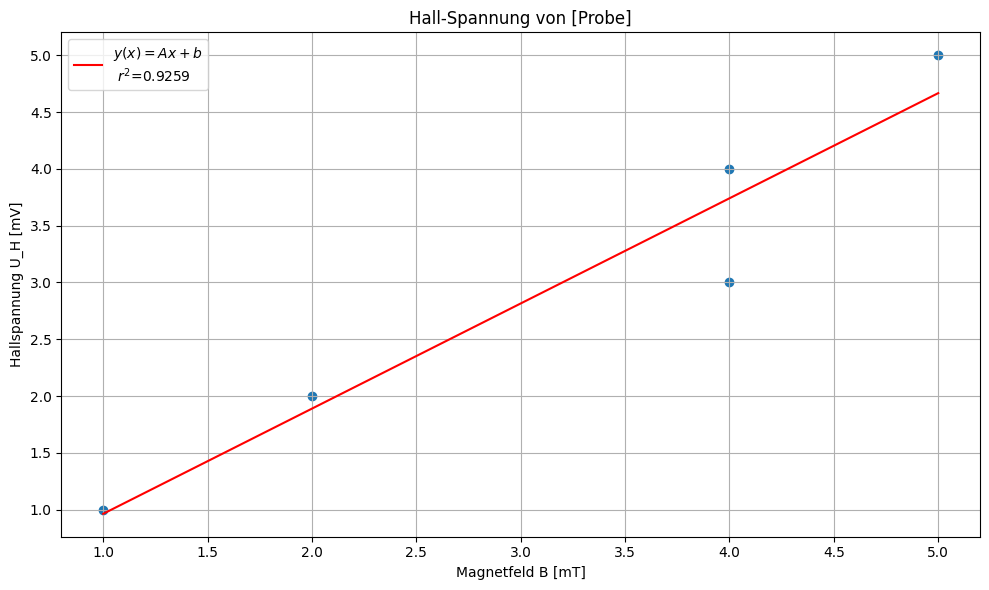

In [ ]:
# Hall-Spannung

# known
l = 20 #mm Länge der Proben
b = 10 #mm Breite der Probe
d = 1 #mm Dicke der Probe
d_p = ufloat(10.0, 0.2) #mm Abstabd der Polschuhe
def B(I_b): 
    '''
    Magnetfeld in Abhängigkeit der angelegten Spannung

    Input : I_b [A]

    Outbput : B [mT]
    '''    
    return ufloat(48.70,0.25)*I_b

# gemessen

# Data

U_H = np.array([1,2,3,4,5]) # mV gemessene Hall-Spannung
B = np.array([1,2,4,4,5]) # mT angelegtes Magnetfeld


# Fit
popt, pcov = curve_fit(Helper.linfit, B, U_H, p0=[1, 1])

a_opt, b_opt = popt
x_model = np.linspace(min(B), max(B), 100)
y_model = Helper.linfit(x_model, a_opt, b_opt)
perr = np.sqrt(np.diag(pcov))

r2 = Helper.r2_curve_fit(popt, B, U_H, Helper.linfit)


# plot
plt.figure(figsize=(10, 6))
plt.scatter(B, U_H)
plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# plt.plot(V, p, "o")
plt.ylabel(r"Hallspannung U_H [mV]")
plt.xlabel(r"Magnetfeld B [mT]")
plt.legend()
plt.title("Hall-Spannung von [Probe]")
plt.tight_layout()
plt.grid()
plt.show()


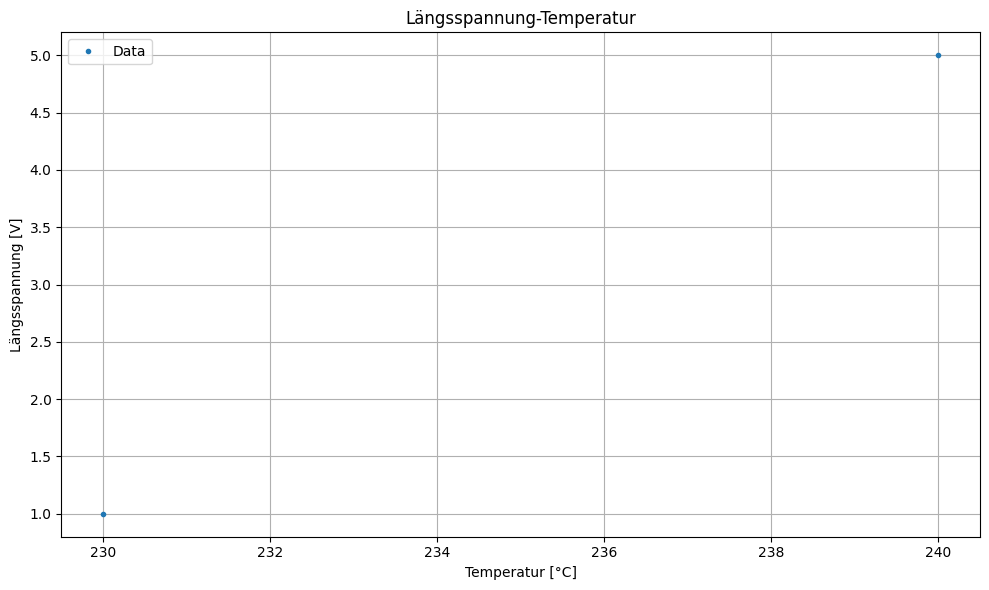

In [10]:
# csv-plots

Data = pd.read_csv("test.csv", sep=',', decimal='.')   # read csv für den Graphen


T = Data["T"].to_numpy()    # Temperatur Data

U = Data["U"].to_numpy()    # Spannung Data


plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
# plt.fill(T, U, color="C0", alpha=0.25, label="eingeschlossene Fläche")
plt.plot(T, U, '.', linewidth=1, label="Data")
plt.xlabel("Temperatur [°C]")
plt.ylabel("Längsspannung [V]")
plt.title("Längsspannung-Temperatur")
plt.legend()
plt.grid()
plt.tight_layout()